#### New data

In [48]:
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches  # For legend patches
import matplotlib.ticker as ticker
import random
import numpy as np

#### 1) Load data

##### 1.1) Available memory

In [49]:
load_df = pd.read_csv("ten_mins_avg_95perc_bounds.csv")
load_df = load_df.rename(columns={"Mean RAM Available":"mean_ram_available"})
load_df['fivemin'] = pd.to_datetime(load_df['fivemin'], format='%H:%M:%S').dt.time
load_df["datetime"] = load_df['fivemin'].apply(lambda t: datetime.datetime.combine(datetime.date.today(), t))
max_memory = load_df["mean_ram_available"].max()

##### 1.2) DAGs

In [50]:
dags_df = pd.read_csv("dags_info_hours_minutes_avg.csv")
dags_df['start_datetime'] = dags_df.apply(
    lambda row: datetime.datetime.combine(
        datetime.date.today(), 
        datetime.time(round(row['hour_start']), round(row['minute_start']))
    ), axis=1
)
dags_df['end_datetime'] = dags_df.apply(
    lambda row: datetime.datetime.combine(
        datetime.date.today(),
        datetime.time(round(row['hour_end']), round(row['minute_end']))
    ), axis=1
)
dags_df["task_id"] = range(len(dags_df["dag_id"]))

#### 2) Define helpful functions

In [51]:
def generate_random_colors(n):
    """
    Generate n random color hex codes.
    
    :param n: Number of colors to generate
    :return: List of n color codes in '#RRGGBB' format
    """
    colors = []
    for _ in range(n):
        r = random.randint(0, 255)
        g = random.randint(0, 255)
        b = random.randint(0, 255)
        colors.append(f'#{r:02X}{g:02X}{b:02X}')
    return colors

def determine_areas_to_move_dags(bound: float, load_df: pd.DataFrame, dag_row: pd.core.series.Series) -> pd.DataFrame:
    """
    Determine areas where to move dags
    
    :param bound: Number that defines the percentage from maximum memory that area should have
    :param load_df: Dataframe with loads
    :param dag_row: A single row from dags_df.iterrows()
    """
    threshold = bound * max_memory
    # Filter only rows meeting the threshold and keep only the 'datetime' column 
    # (this reduces memory usage by discarding unused columns)
    filtered = load_df.loc[load_df['mean_ram_available'] >= threshold, ['datetime']]
    # Compute group keys on the fly using the index (avoiding creating an extra column)
    group_keys = (filtered.index.to_series().diff() != 1).cumsum()
    # Aggregate the datetime to get start and end of each continuous group
    agg_df = filtered.groupby(group_keys)['datetime'].agg(['min', 'max'])
    agg_df.rename(columns={'min': 'start_datetime', 'max': 'end_datetime'}, inplace=True)
    # Calculate the duration of each interval
    agg_df['duration'] = agg_df['end_datetime'] - agg_df['start_datetime']
    # Filter intervals that are longer than 30 minutes
    agg_df = agg_df[(agg_df['duration'] > dag_row["dag_duration"])]
    agg_df["dag_id"] = row["dag_id"]
    print(agg_df)
    return agg_df

#### 3) Setting up displaying top N memory usages

In [52]:
n = 5
color_list = generate_random_colors(n)
df_time_smallest_memory = load_df.nsmallest(n = n, columns="mean_ram_available")

#### 4) Filtering out dags that are not running at minimum memory times

In [53]:
# option1
lst = []
for x in df_time_smallest_memory["datetime"].to_list():
    lst.append(dags_df[(dags_df["start_datetime"] <= x) & (x <= dags_df["end_datetime"])])
dags_df = pd.concat(lst).drop_duplicates()

#### 5) Limiting data in load_df by 4 hours before the earliest maxLoad and by 4 hours after the latest maxLoad

In [54]:
n_hours_upfront = 2
n_hours_behind = 5
delayed_load_df = load_df.copy()
delayed_load_df["datetime"] = delayed_load_df["datetime"] - pd.Timedelta(days=1)
min_time = df_time_smallest_memory['datetime'].min()
max_time = df_time_smallest_memory['datetime'].max()
day_start = min_time.normalize()  # sets time to 00:00:00
day_end = day_start + pd.Timedelta(days=1)  # this is 24:00:00 (i.e., start of the next day)
candidate_lower = min_time - pd.Timedelta(hours=n_hours_behind)
candidate_upper = max_time + pd.Timedelta(hours=n_hours_upfront)
'''
load_df data within the same day
'''
# lower_bound = candidate_lower if candidate_lower >= day_start else day_start
# upper_bound = candidate_upper if candidate_upper <= day_end else day_end
# load_df = load_df[(load_df['datetime'] >= lower_bound) & (load_df['datetime'] <= upper_bound)]
'''
load_df data without limiting on the same day
'''
load_df = pd.concat([delayed_load_df, load_df])
load_df = load_df[(load_df['datetime'] >= candidate_lower) \
                  & (load_df['datetime'] <= candidate_upper)]

#### Setting up the plot

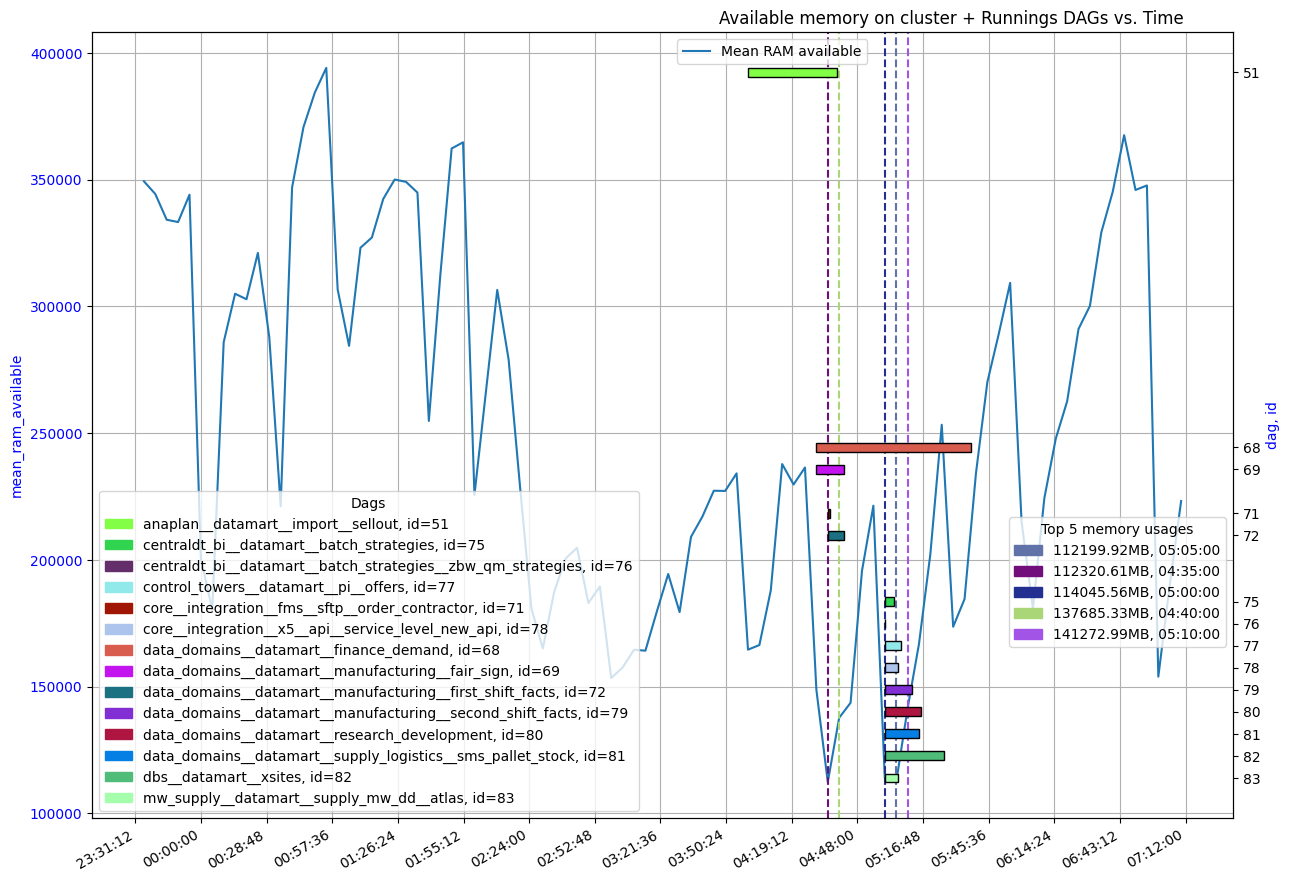

In [55]:
fig, ax1 = plt.subplots(figsize=(13, 9))   # ax1: for measurements (left y-axis)
ax2 = ax1.twinx()                         # ax2: for Gantt bars (right y-axis)
ax1.grid()
line1, = ax1.plot(load_df['datetime'], load_df["mean_ram_available"], label="Mean RAM available")
# line2, = ax1.plot(load_df['datetime'], load_df["95up"],                label="0.95_confidence_interval_up")
# line3, = ax1.plot(load_df['datetime'], load_df["95down"],             label="95down")
ax3 = fig.add_subplot(1,2,2)
handles, labels = ax1.get_legend_handles_labels()
legend_obj = ax3.legend(handles, labels, loc="upper left")
ax3.axis("off")
ax3.set_title("Lines")

ax1.legend()
# ax1.legend(loc="upper left")

ax1.set_ylabel("mean_ram_available", color="blue")
ax2.set_ylabel("dag, id", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

# coloring topN memory usages
legend_handles = []
for i, row in df_time_smallest_memory.reset_index().iterrows():
        task_label = f"{round(row["mean_ram_available"], 2)}MB, {row["datetime"].strftime('%X')}"
        patch = mpatches.Patch(color=color_list[i], label=task_label)
        ax1.axvline(
            x=row["datetime"], 
            color=color_list[i], 
            linestyle="--", 
            label=f"Top{i+1} memory usage {round(row["mean_ram_available"], 2)}MB at {row["datetime"].strftime('%s:%m:%s')})"
        )
        legend_handles.append(patch)

# coloring dags
color_list = generate_random_colors(len(dags_df["dag_id"].drop_duplicates()))
color_dct = {dag_name:color for color, dag_name in zip(color_list, dags_df["dag_id"].drop_duplicates())}
for _, row in dags_df.iterrows():
    # Convert start/end to numeric for bar width
    left1  = mdates.date2num(row["start_datetime"])
    width1 = mdates.date2num(row["end_datetime"]) - left1
    c = color_list[row["task_id"] % len(color_list)]
    # Draw first bar
    ax2.barh(y=row["task_id"], 
                width=width1, 
                left=left1, 
                height=0.4, 
                color=color_dct[row["dag_id"]], 
                edgecolor="black")

# Define areas where to move DAG
#-------------------------------
'''
lst = []
i = 0
for _, row in df_time_smallest_memory.iterrows():
    i+=1
    y = dags_df[(dags_df["start_datetime"] <= row["datetime"]) \
                & (row["datetime"] <= dags_df["end_datetime"])].copy()
    y["min_memory_intersection_datetime"] = row["datetime"]
    y["min_memory_intersection_memory"] = row["mean_ram_available"]
    y["min_memory_num"] = i
    lst.append(y)
tmp_dags_df = pd.concat(lst).drop_duplicates()
tmp_dags_df["dag_duration"] = tmp_dags_df["end_datetime"] - tmp_dags_df["start_datetime"]
tmp_dags_df[tmp_dags_df["min_memory_num"] == 3].sort_values(by=["dag_duration"], ascending=False)
available_areas_lst = []
for _, row in tmp_dags_df[tmp_dags_df["dag_id"] == "data_domains__datamart__finance_mcc"].sort_values(by=["dag_duration"], ascending=False).head(1).iterrows():
    available_areas_lst.append(determine_areas_to_move_dags(0.4, load_df, row))
# TODO: for showing the area for two or more dags the next section should rewritten
available_areas_df = pd.concat(available_areas_lst)
available_areas_df = available_areas_df[available_areas_df["start_datetime"] < df_time_smallest_memory["datetime"].max()]
for _, row in available_areas_df.iterrows():
    ax1.axvspan(
        row["start_datetime"],  # xmin
        row["end_datetime"],  # xmax
        color=color_dct[row["dag_id"]],
        alpha=0.3,            # transparency
        animated=True
    )
'''
#-------------------------------    

legend_handles2 = []
unique_tasks = dags_df.drop_duplicates(subset=["dag_id"]).sort_values("dag_id")

for i, row in unique_tasks.iterrows():
#     if len(available_areas_df[available_areas_df["dag_id"] == row["dag_id"]]) != 0:
#         task_label = f"""{row['dag_id']}, id={row["task_id"]}, 
#             available areas are:
#             {(available_areas_df[available_areas_df["dag_id"] == row["dag_id"]][["start_datetime","end_datetime", "duration"]])}"""
#     else:
#         task_label = f"{row['dag_id']}, id={row["task_id"]}"
    task_label = f"{row['dag_id']}, id={row["task_id"]}"
    c = color_dct[row["dag_id"]]
    patch = mpatches.Patch(color=c, label=task_label)
    legend_handles2.append(patch)
ax2.legend(handles=legend_handles2
           , title="Dags"
           , loc="lower left")
ax1.legend(handles=legend_handles
           , title=f"Top {len(df_time_smallest_memory)} memory usages"
           , loc="center right"
           , bbox_to_anchor=(1, 0.3))
# Label the tasks on the right axis
ax2.set_yticks(dags_df["task_id"])
ax2.set_yticklabels(dags_df["task_id"])
ax2.invert_yaxis()  # so first task appears at the top


# ---------------------------------------------------------------------
# 6. Format the X-axis as dates
# ---------------------------------------------------------------------
# We can format just ax1 (they share the same x-axis)
# ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
#     ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_locator(ticker.MaxNLocator(20))

fig.autofmt_xdate()

# ---------------------------------------------------------------------
# 7. Show / save the figure
# ---------------------------------------------------------------------
plt.title("Available memory on cluster + Runnings DAGs vs. Time")
plt.tight_layout()

# Format the x-axis to display times
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.show()

#### New approach

In [1]:
import pandas as pd
import json

with open('output.json') as data_file:
    data = json.load(data_file)

df = pd.concat(
    [
        pd.DataFrame(data['metrics'][0]['timeseries']['timestamps'], columns=['time']), 
        pd.DataFrame(data['metrics'][0]['timeseries']['doubleValues'], columns=['value']),    
    ], 
    axis=1
)
df['datetime'] = pd.to_datetime(df['time'], unit='ms')
df_dags = pd.read_csv('dags_info_hours_minutes.csv')
df_ram = df

# Step 1: Find the lowest available memory each day between 2 AM and 6 AM
df_ram['date'] = df_ram['datetime'].dt.date
df_ram['hour'] = df_ram['datetime'].dt.hour
df_ram.value = df_ram.value.astype(float)

# Filter data between 2 AM and 6 AM
df_ram_night = df_ram[(df_ram['hour'] >= 2) & (df_ram['hour'] <= 6)]


FileNotFoundError: [Errno 2] No such file or directory: 'output.json'

In [2]:
df_ram_night.info()

NameError: name 'df_ram_night' is not defined

In [8]:
df_ram_night.head()

,time,value,datetime,date,hour
23,1742781600000,260471.466667,2025-03-24 02:00:00,2025-03-24,2
24,1742781900000,326587.733333,2025-03-24 02:05:00,2025-03-24,2
25,1742782200000,340821.333333,2025-03-24 02:10:00,2025-03-24,2
26,1742782500000,233881.600000,2025-03-24 02:15:00,2025-03-24,2
27,1742782800000,103901.866667,2025-03-24 02:20:00,2025-03-24,2


In [9]:
# Find the lowest memory moment for each day
lowest_memory_moments = df_ram_night.loc[df_ram_night.groupby('date')['value'].idxmin()]

# Step 2: For each lowest memory moment, find DAGs running at that time
def dags_running_at(moment, dags_df):
    moment_month = moment.month
    moment_day = moment.day
    moment_hour = moment.hour
    moment_minute = moment.minute

    running_dags = dags_df[
        (
            (dags_df['month_start'] < moment_month) | 
            ((dags_df['month_start'] == moment_month) & (dags_df['day_start'] < moment_day)) |
            ((dags_df['month_start'] == moment_month) & (dags_df['day_start'] == moment_day) &
             ((dags_df['hour_start'] < moment_hour) | ((dags_df['hour_start'] == moment_hour) & (dags_df['minute_start'] <= moment_minute))))
        ) &
        (
            (dags_df['month_end'] > moment_month) | 
            ((dags_df['month_end'] == moment_month) & (dags_df['day_end'] > moment_day)) |
            ((dags_df['month_end'] == moment_month) & (dags_df['day_end'] == moment_day) &
             ((dags_df['hour_end'] > moment_hour) | ((dags_df['hour_end'] == moment_hour) & (dags_df['minute_end'] >= moment_minute))))
        )
    ]

    return running_dags['dag_id'].tolist()

# Step 3: Count how often each DAG runs at lowest memory moments
from collections import Counter

dag_counts = Counter()

for _, row in lowest_memory_moments.iterrows():
    running_dags = dags_running_at(row['datetime'], df_dags)
    dag_counts.update(running_dags)

# Resulting counts DataFrame
result_df = pd.DataFrame(dag_counts.items(), columns=['dag_id', 'run_count']).sort_values(by='run_count', ascending=False)

print(result_df)

                                               dag_id  run_count
1   anaplan__datamart__demand_planning__sellout_facts         30
26   pricing_and_promo__integration__tpo_5ka__anaplan         27
0   centraldt_bi__integration__atlas_vostok__s3__c...         26
3             mw_core__integration__orion__oracle__mw         25
15                      mw_core__datamart__atlas__soh         23
..                                                ...        ...
88  pricing_and_promo__datamart__hyperglobus_baseline          1
89        pricing_and_promo__datamart__lenta_baseline          1
90                   core__datamart__compass__compute          1
91     control_towers__datamart__value_chain__kpi_rpc          1
92         pricing_and_promo__datamart__okey_baseline          1

[93 rows x 2 columns]


In [3]:
lowest_memory_moments.head(2)

,time,value,datetime,date,hour
60,1740373200000,9625.6,2025-02-24 05:00:00,2025-02-24,5
349,1740459900000,245760.0,2025-02-25 05:05:00,2025-02-25,5


#### second approach

In [10]:
import pandas as pd

# Assuming df_ram and df_dags are already defined.

# Step 1: Find maximum available RAM and calculate 10% threshold
max_ram = df_ram['value'].max()
threshold = max_ram * 0.1

# Step 2: Filter for times between 2 AM and 6 AM, inclusive
df_ram_filtered = df_ram[df_ram['datetime'].dt.hour.between(2, 3)]

# Step 3: Further filter only datetimes with RAM <= threshold
df_ram_low = df_ram_filtered[df_ram_filtered['value'] <= threshold].copy()

# Extract date for joining purpose
df_ram_low['date'] = df_ram_low['datetime'].dt.date

# Step 4: Prepare df_dags with proper datetime columns
df_dags['start_datetime'] = pd.to_datetime(dict(year=2025, month=df_dags['month_start'], day=df_dags['day_start'], hour=df_dags['hour_start'], minute=df_dags['minute_start']))
df_dags['end_datetime'] = pd.to_datetime(dict(year=2025, month=df_dags['month_end'], day=df_dags['day_end'], hour=df_dags['hour_end'], minute=df_dags['minute_end']))

# Step 5: Join df_ram_low and df_dags based on overlapping datetime intervals
# We find all dags running during any low-memory timestamp
result_rows = []

for idx, ram_row in df_ram_low.iterrows():
    ram_time = ram_row['datetime']
    running_dags = df_dags[(df_dags['start_datetime'] <= ram_time) & (df_dags['end_datetime'] >= ram_time)].copy()
    running_dags['low_ram_datetime'] = ram_time
    running_dags['available_ram'] = ram_row['value']
    result_rows.append(running_dags)

# Concatenate all results into a single DataFrame
final_df = pd.concat(result_rows, ignore_index=True)

# Step 6: Get dags running on lowest memory in at least half of the observed days
# Count total unique days with low memory
total_days = df_ram_low['date'].nunique()
half_days = total_days / 2

# Add 'date' to final_df for grouping
final_df['date'] = final_df['low_ram_datetime'].dt.date

# Count unique days each DAG appears in
dag_day_counts = final_df.groupby('dag_id')['date'].nunique().reset_index()
dag_day_counts = dag_day_counts[dag_day_counts['date'] >= half_days]

# Filter original final_df to keep only those DAGs
popular_dags_df = final_df[final_df['dag_id'].isin(dag_day_counts['dag_id'])]

In [57]:
top_10 = final_df.drop_duplicates(subset=["dag_id", "start_datetime", "end_datetime"]) \
    [["dag_id", "start_datetime"]] \
    .groupby('dag_id').count() \
    .rename(columns={'start_datetime': 'cnt_appearances'}) \
    .sort_values(by=['cnt_appearances', 'dag_id'], ascending=False) \
    .reset_index() \
    .head(15)
print(top_10)

                                               dag_id  cnt_appearances
0    pricing_and_promo__integration__tpo_5ka__anaplan               76
1    data_domains__datamart__manufacturing__fair_sign               43
2      core__integration__fms__sftp__order_contractor               40
3             mw_core__integration__orion__oracle__mw               30
4   anaplan__datamart__demand_planning__sellout_facts               30
5                       mw_core__datamart__atlas__soh               29
6   centraldt_bi__integration__atlas_vostok__s3__c...               29
7                     anaplan__datamart__import__cogs               29
8      anaplan__datamart__import__atlas_currency_rate               29
9   mw_sales__export__chicago__russia_petcarefood_...               28
10  data_domains__integration__workday__api__reloa...               28
11  data_domains__datamart__customer_marketing_ins...               28
12           core__datamart__spm_sp__sharepoint_files               28
13    